In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import pickle
import time
from copy import deepcopy

import torch  # imported first on purpose: on Windows it must win the DLL search over matplotlib/sklearn

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tabulate import tabulate

from datasets.cardio import infer_node_types, load_cardio_dataframe
from utils.cardio import (
    derive_kaam_mixed_variants,
    evaluate_cardio_observational,
    fit_cardio_model,
    sweep_beta_weight,
)
from utils.paths import get_experiment_paths

print(f'python : {sys.executable}')
print(f'torch  : {torch.__version__}')

python : c:\Users\aarna\miniconda3\envs\TFM_clau\python.exe
torch  : 2.13.0+cpu


In [2]:
# Load the dataset
data_cardio = load_cardio_dataframe()

print(data_cardio.head())
print(f'Number of patients: {len(data_cardio)}')


   ischemia  macv  age  systolic   bmi  diabetes
0         1     1   39       106  27.0         0
1         0     0   46       121  28.7         0
2         0     0   48       128  25.3         0
3         0     1   61       150  28.6         0
4         0     0   46       130  23.1         0
Number of patients: 4415


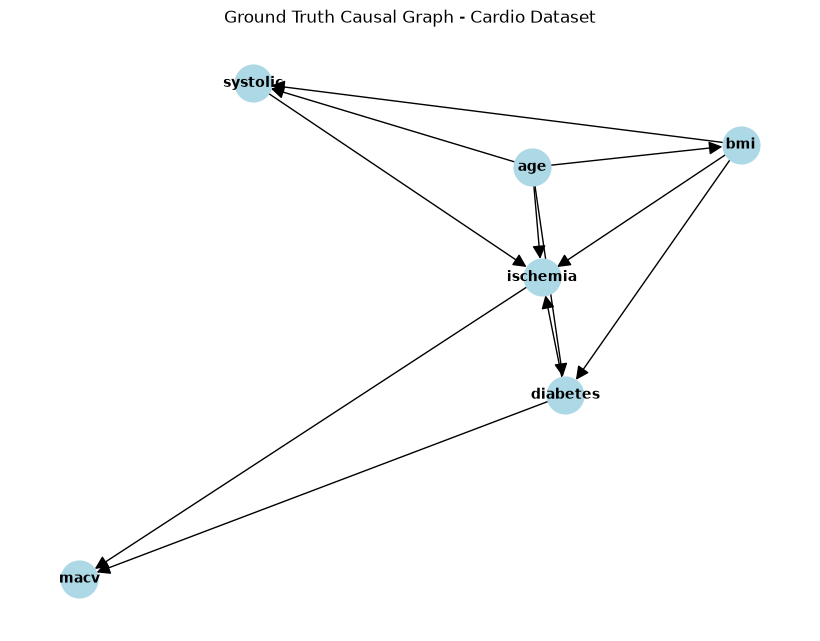

In [3]:
# Graph defined by our reference paper
graph_cardio = nx.DiGraph([('age', 'diabetes'), ('age', 'systolic'), ('age', 'ischemia'), ('age', 'bmi'),
                            ('bmi', 'systolic'), ('bmi', 'ischemia'), ('bmi', 'diabetes'),
                            ('systolic', 'ischemia'),
                            ('diabetes', 'macv'), ('diabetes', 'ischemia'),
                            ('ischemia', 'macv')])

# Show the ground truth graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph_cardio)
nx.draw(graph_cardio, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
plt.title("Ground Truth Causal Graph - Cardio Dataset")
plt.show()

Train set shape: (2207, 6), Test set shape: (2208, 6)


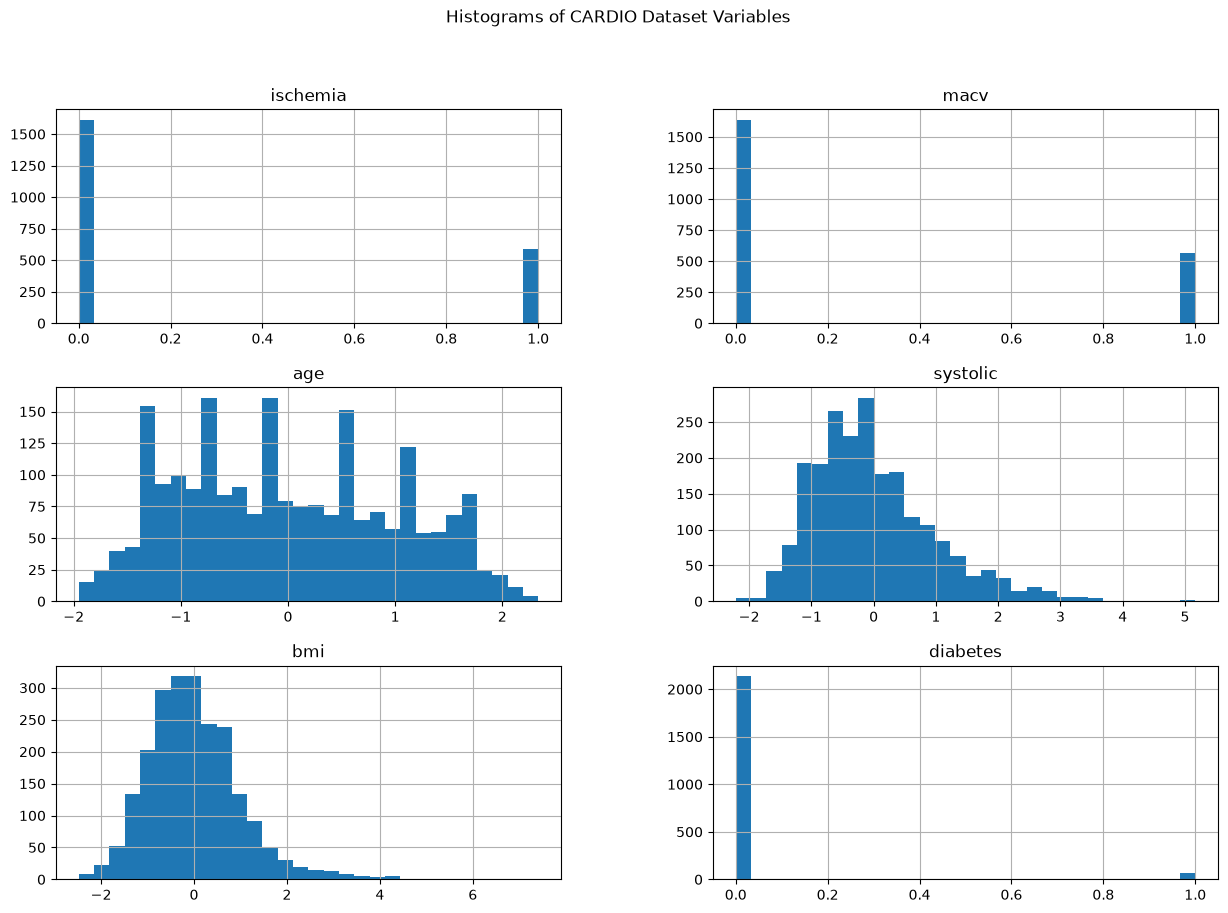

In [4]:
# Prepare the values for the later analysis
split_eval = 0.5  # Use half of the samples for training and half for evaluation
np.random.seed(42)  # Set seed for repeatability

factual_train_d, factual_eval_d = train_test_split(data_cardio, test_size=split_eval, random_state=42)
nodes = factual_train_d.columns

# Some nodes are continuous and some are discrete: preprocess accordingly
int_min_val = -3
int_max_val = 3
int_step = 0.1
int_vector_values = np.arange(int_min_val, int_max_val, int_step)  # This is for continuous nodes

node_info = {}
for node in nodes:
    node_info[node] = {}
    # First, assess if the node is continuous or discrete
    if len(factual_train_d[node].unique()) > 5:
        node_info[node]['type'] = 'continuous'
        node_info[node]['mean'] = factual_train_d[node].mean()
        node_info[node]['std'] = factual_train_d[node].std()
        factual_train_d[node] = (factual_train_d[node] - node_info[node]['mean']) / node_info[node]['std']
        factual_eval_d[node] = (factual_eval_d[node] - node_info[node]['mean']) / node_info[node]['std']
        node_info[node]['int_values'] = tuple(int_vector_values)
        node_info[node]['percentile_25'] = np.percentile(factual_eval_d[node], 25)
        node_info[node]['percentile_75'] = np.percentile(factual_eval_d[node], 75)
        node_info[node]['percentile_50'] = np.median(factual_eval_d[node])
    else:
        node_info[node]['type'] = 'discrete'
        node_info[node]['int_values'] = (0, 1) # In this dataset, all discrete variables are binary

def post_process_samples(df, denorm=False):
    for node in df.columns:
        if node_info[node]['type'] == 'discrete':
            df[node] = df[node].astype(int)
            df[node] = np.clip(df[node], min(node_info[node]['int_values']), max(node_info[node]['int_values']))
    if denorm:
        for node in df.columns:
            if node_info[node]['type'] == 'continuous':
                df[node] = df[node] * node_info[node]['std'] + node_info[node]['mean']
    return df

print(f'Train set shape: {factual_train_d.shape}, Test set shape: {factual_eval_d.shape}')

paths = get_experiment_paths('cardio')
results_bdir = str(paths.root)
images_dir = str(paths.images)
samples_dir = str(paths.samples)
data_dir = str(paths.data)

factual_train_d.to_csv(os.path.join(data_dir, 'cardio_factual_train_d.csv'), index=False)
factual_eval_d.to_csv(os.path.join(data_dir, 'cardio_factual_eval_d.csv'), index=False)

# Stored so cardio_hsic_results.ipynb can denormalise its axes without re-deriving the split
with open(os.path.join(data_dir, 'cardio_node_info.pkl'), 'wb') as f:
    pickle.dump(node_info, f, protocol=pickle.HIGHEST_PROTOCOL)

# Create a continuous version of the data by adding small noise to the discrete values (used for training in continuous models)
factual_train_dn = factual_train_d + np.random.normal(0, 0.01, factual_train_d.shape)
factual_train_dn.to_csv(os.path.join(samples_dir, f"cardio_factual_train_dn.csv"), index=False)

# Show a histogram of all the variables in the dataset, both of train and test
factual_train_d.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of CARDIO Dataset Variables")
plt.show()

In [ ]:
# Configuration for the training runs.
# The 'kan', 'kaam' and 'anm' baselines are intentionally excluded: this notebook only
# covers the mixed KAN family plus the DBCM and causal-flow baselines. KAAM is trained
# first so cardio_hsic_results.ipynb can analyse the symbolic mechanisms as early as possible.
MODEL_NAMES = ['kaam_mixed', 'kan_mixed', 'dbcm', 'flow']

# Hybrid loss weight for the KAN family, with alpha = 1 - beta (Experimento1 convention):
#   loss = alpha * MSE/Var(Y) + beta * nHSIC(parents, residual)
BETA_VALUES = [round(float(b), 2) for b in np.arange(0.0, 0.9, 0.1)]  # 0.0 ... 0.8

verbose = True
n_threads = 9

node_types, num_classes = infer_node_types(factual_train_d, default_num_classes=2)

models = {}
results = {}
best_params = {}
arch_params = {}
beta_sweeps = {}

root_nodes = [n for n in graph_cardio.nodes if graph_cardio.in_degree(n) == 0]
beta_nodes = [n for n in graph_cardio.nodes if graph_cardio.in_degree(n) > 0 and node_types[n] == 'continuous']

print(f'Models        : {MODEL_NAMES}')
print(f'Beta values   : {BETA_VALUES}')
print(f'Node types    : {node_types}')
print(f'Root nodes    : {root_nodes}  (fitted as a normal distribution, no KAN and no beta)')
print(f'Beta searched : {beta_nodes}  (continuous non-root nodes only)')
print(f'Cross-entropy : {[n for n in graph_cardio.nodes if graph_cardio.in_degree(n) > 0 and node_types[n] == "discrete"]}  (no residual, so beta is inert)')

Models        : ['kaam_mixed', 'kan_mixed', 'dbcm', 'flow']
Beta values   : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
Node types    : {'ischemia': 'discrete', 'macv': 'discrete', 'age': 'continuous', 'systolic': 'continuous', 'bmi': 'continuous', 'diabetes': 'discrete'}
Root nodes    : ['age']  (fitted as a normal distribution, no KAN and no beta)
Beta searched : ['systolic', 'bmi']  (continuous non-root nodes only)
Cross-entropy : ['diabetes', 'ischemia', 'macv']  (no residual, so beta is inert)


In [6]:
# Shared evaluate-and-persist step, so each model cell below stays a single training call.
# Writes exactly the artefacts the previous flow produced, one set per model name.
def evaluate_and_store(name, model, sample_seed=42):
    metrics, obs_samples, residuals, extras = evaluate_cardio_observational(
        name, model, factual_eval_d, node_info, sample_seed=sample_seed
    )
    results.setdefault(name, {'model': name})
    results[name].update(metrics)

    obs_samples.to_csv(os.path.join(samples_dir, f'cardio_obs_samples_{name}.csv'), index=False)
    with open(os.path.join(samples_dir, f'cardio_obs_samples_{name}.pkl'), 'wb') as f:
        pickle.dump(obs_samples, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(samples_dir, f'cardio_residuals_{name}.pkl'), 'wb') as f:
        pickle.dump(residuals, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(data_dir, f'cardio_results_{name}.pkl'), 'wb') as f:
        pickle.dump(results[name], f, protocol=pickle.HIGHEST_PROTOCOL)

    # Only kaam_mixed_symbolic carries formulas; this file feeds the results notebook.
    if extras.get('formulas'):
        with open(os.path.join(samples_dir, 'cardio_formulas_kaam.pkl'), 'wb') as f:
            pickle.dump(extras['formulas'], f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f'  formulas -> cardio_formulas_kaam.pkl')
        for node, formula in extras['formulas'].items():
            print(f'    {node} = {formula}')

    shown = {k: round(float(v), 4) for k, v in metrics.items()}
    print(f"  {name}: {shown}")
    return metrics


def report_selected_beta(name):
    """Print the beta chosen per node, for the models where it was searched."""
    if name not in best_params:
        return
    chosen = {node: p.get('beta_weight') for node, p in best_params[name].items()}
    searched = {node: b for node, b in chosen.items() if node in beta_nodes}
    print(f"  selected beta (searched nodes): {searched}")

In [7]:
# STAGE 1 is no longer searched here: the architecture per node is the one already selected by
# the reference cardio grid search (243 combinations, criterion rf_acc[node] + rf_acc['all']),
# transcribed from notebooks/alejandro/cardio.ipynb. Only beta is searched, in stage 2 below.
KAN_SHARED_PARAMS = dict(batch_size=-1, seed=0, early_stop=True, steps=10000,
                         lamb_entropy=0.1, sparse_init=False, try_gpu=False, loss='mse')

# Only these six keys varied across the grid; everything else is the shared block above.
SELECTED_ARCH_PARAMS = {
    'kan_mixed': {
        'diabetes': dict(hidden_dim=5, grid=5, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
        'systolic': dict(hidden_dim=5, grid=10, k=10, lr=0.001, lamb=0.001, mult_kan=True),
        'ischemia': dict(hidden_dim=5, grid=10, k=10, lr=0.001, lamb=0.001, mult_kan=True),
        'bmi': dict(hidden_dim=0, grid=1, k=10, lr=0.001, lamb=0.1, mult_kan=False),
        'macv': dict(hidden_dim=0, grid=10, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
    },
    # KAAM stays on hidden_dim=0 / mult_kan=False so its activations remain symbolically extractable.
    'kaam_mixed': {
        'diabetes': dict(hidden_dim=0, grid=10, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
        'systolic': dict(hidden_dim=0, grid=10, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
        'ischemia': dict(hidden_dim=0, grid=1, k=1, lr=0.001, lamb=0.001, mult_kan=False),
        'bmi': dict(hidden_dim=0, grid=1, k=10, lr=0.001, lamb=0.1, mult_kan=False),
        'macv': dict(hidden_dim=0, grid=10, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
    },
}

# The baselines have no beta stage, so these are the final parameters used at fit time.
SELECTED_DBCM_PARAMS = dict(num_epochs=500, lr=0.01, batch_size=32, hidden_dim=128)
SELECTED_FLOW_PARAMS = dict(flow_type='CausalNSF', hidden_dims=(32, 32), base_lr=0.01,
                            early_stopping_patience=30, scheduler=None, batch_size=256,
                            train_val_split=(0.8, 0.2), max_epochs=1000, device='cpu', bins=8)

non_root_nodes = {n for n in graph_cardio.nodes if graph_cardio.in_degree(n) > 0}
for name in ['kan_mixed', 'kaam_mixed']:
    missing = non_root_nodes - set(SELECTED_ARCH_PARAMS[name])
    assert not missing, f'{name}: no selected architecture for {sorted(missing)}'
    # node_types / num_classes come from THIS split, not from the reference run.
    arch_params[name] = {
        node: {**KAN_SHARED_PARAMS, **varied, 'node_types': node_types, 'num_classes': num_classes}
        for node, varied in SELECTED_ARCH_PARAMS[name].items()
    }

print('Stage 1 skipped: using the pre-selected architecture (no grid search).')
for name, params in arch_params.items():
    print(f'\n{name}')
    for node, p in params.items():
        print(f"  {node:9s} hidden_dim={p['hidden_dim']}  grid={p['grid']}  k={p['k']}  "
              f"lr={p['lr']}  lamb={p['lamb']}  mult_kan={p['mult_kan']}")

Stage 1 skipped: using the pre-selected architecture (no grid search).

kan_mixed
  diabetes  hidden_dim=5  grid=5  k=10  lr=0.0001  lamb=0.001  mult_kan=False
  systolic  hidden_dim=5  grid=10  k=10  lr=0.001  lamb=0.001  mult_kan=True
  ischemia  hidden_dim=5  grid=10  k=10  lr=0.001  lamb=0.001  mult_kan=True
  bmi       hidden_dim=0  grid=1  k=10  lr=0.001  lamb=0.1  mult_kan=False
  macv      hidden_dim=0  grid=10  k=10  lr=0.0001  lamb=0.001  mult_kan=False

kaam_mixed
  diabetes  hidden_dim=0  grid=10  k=10  lr=0.0001  lamb=0.001  mult_kan=False
  systolic  hidden_dim=0  grid=10  k=10  lr=0.0001  lamb=0.001  mult_kan=False
  ischemia  hidden_dim=0  grid=1  k=1  lr=0.001  lamb=0.001  mult_kan=False
  bmi       hidden_dim=0  grid=1  k=10  lr=0.001  lamb=0.1  mult_kan=False
  macv      hidden_dim=0  grid=10  k=10  lr=0.0001  lamb=0.001  mult_kan=False


In [ ]:
# STAGE 2: sweep the hybrid weight beta over the stage-1 architecture, one whole-model fit
# per beta. Selection uses the SAME criterion as stage 1 and as the DBCM/flow searches:
# minimise RF accuracy, specifically rf_acc[node] + rf_acc['all'].
#
# Beta is only selected for continuous non-root nodes. kan_model_mixed trains discrete nodes
# with cross-entropy, so they have no additive-noise residual for the HSIC term to act on and
# their fit is identical at every beta.
t0 = time.time()

for name in ['kaam_mixed', 'kan_mixed']:
    best_params[name], sweep = sweep_beta_weight(
        name, arch_params[name], BETA_VALUES, graph_cardio,
        factual_train_d, factual_eval_d, num_classes,
        node_types=node_types, n_jobs=n_threads, verbose=verbose,
    )
    beta_sweeps[name] = sweep
    sweep.to_csv(os.path.join(data_dir, f'cardio_beta_sweep_{name}.csv'), index=False)
    with open(os.path.join(data_dir, f'best_beta_{name}_cardio.pkl'), 'wb') as f:
        pickle.dump({node: p['beta_weight'] for node, p in best_params[name].items()}, f,
                    protocol=pickle.HIGHEST_PROTOCOL)

print(f'\nStage 2 finished in {time.time() - t0:.1f}s')

for name, sweep in beta_sweeps.items():
    searched = sweep[sweep['searched']]
    print(f'\n=== {name}: criterion rf_acc[node] + rf_acc["all"] (lower is better) ===')
    print(searched.pivot_table(index='beta', columns='node', values='criterion').round(4).to_string())
    chosen = {row['node']: row['beta'] for _, row in searched[searched['selected']].iterrows()}
    print(f'selected beta: {chosen}')

Sweeping beta for kaam_mixed on cardio over 9 values: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


In [ ]:
# ---------------------------------------------------------------- KAAM mixed (trained first)
# Also derives the pruned and symbolic variants: to_symbolic is what produces
# cardio_formulas_kaam.pkl, the input to the ischemia analysis in the results notebook.
name = 'kaam_mixed'
report_selected_beta(name)

model, training_time, _ = fit_cardio_model(
    name, graph_cardio, best_params[name], factual_train_d, factual_train_dn, seed=42
)
models[name] = model
results[name] = {'model': name, 'training_time': training_time}
print(f'{name} trained in {training_time:.1f}s')

variants = derive_kaam_mixed_variants(model, factual_train_d, seed=42)
for variant_name, (variant_model, variant_time) in variants.items():
    models[variant_name] = variant_model
    results[variant_name] = {'model': variant_name, 'training_time': variant_time}
    print(f'{variant_name} derived in {variant_time:.1f}s')

for variant_name in [name, 'kaam_mixed_pruned', 'kaam_mixed_symbolic']:
    evaluate_and_store(variant_name, models[variant_name])

In [ ]:
# ------------------------------------------------------------------------------- KAN mixed
name = 'kan_mixed'
report_selected_beta(name)

model, training_time, _ = fit_cardio_model(
    name, graph_cardio, best_params[name], factual_train_d, factual_train_dn, seed=42
)
models[name] = model
results[name] = {'model': name, 'training_time': training_time}
print(f'{name} trained in {training_time:.1f}s')

evaluate_and_store(name, model)

In [ ]:
# ------------------------------------------------------------------------------------ DBCM
# Baseline: no beta to search, so it trains straight from the pre-selected parameters.
name = 'dbcm'
best_params[name] = deepcopy(SELECTED_DBCM_PARAMS)
print(f'{name} params: {best_params[name]}')

model, training_time, _ = fit_cardio_model(
    name, graph_cardio, best_params[name], factual_train_d, factual_train_dn, seed=42
)
models[name] = model
results[name] = {'model': name, 'training_time': training_time}
print(f'{name} trained in {training_time:.1f}s')

evaluate_and_store(name, model)

In [ ]:
# ---------------------------------------------------------------------------- Causal flow
name = 'flow'
best_params[name] = deepcopy(SELECTED_FLOW_PARAMS)
print(f'{name} params: {best_params[name]}')

model, training_time, _ = fit_cardio_model(
    name, graph_cardio, best_params[name], factual_train_d, factual_train_dn, seed=42
)
models[name] = model
results[name] = {'model': name, 'training_time': training_time}
print(f'{name} trained in {training_time:.1f}s')

evaluate_and_store(name, model)

In [ ]:
# Consolidate every trained model into one results file and print the comparison table.
with open(os.path.join(data_dir, 'cardio_results_all.pkl'), 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

metric_columns = ['training_time', 'mmd_obs_avg', 'rf_acc_obs_avg', 'hsic', 'dhsic', 'mae']
summary = pd.DataFrame(results).T.reindex(columns=['model'] + metric_columns).reset_index(drop=True)
summary[metric_columns] = summary[metric_columns].apply(pd.to_numeric, errors='coerce')
print(tabulate(summary.round(4), headers='keys', tablefmt='github', showindex=False))
summary.to_csv(os.path.join(data_dir, 'cardio_results_summary.csv'), index=False)

# Beta chosen per node, for the two models where it was searched.
beta_rows = []
for name, params in best_params.items():
    if name not in beta_sweeps:
        continue
    for node in beta_nodes:
        beta_rows.append({'model': name, 'node': node, 'beta': params[node]['beta_weight'],
                          'alpha': params[node]['alpha_weight']})
if beta_rows:
    print('\nSelected hybrid weights (continuous non-root nodes):')
    print(tabulate(pd.DataFrame(beta_rows), headers='keys', tablefmt='github', showindex=False))

print(f'\nArtefacts written to:\n  {data_dir}\n  {samples_dir}')